In [1]:
import torch

In [2]:
torch.manual_seed(42)

Architecture:
2 hidden layers
relu activation function
tanh activation function
sigmoid output

In [ ]:
from torch import float32


class NeuralNetwork():
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, bias_value):
        self.W1 = torch.randn(input_size, hidden_size1)
        self.W2 = torch.randn(hidden_size1, hidden_size2)
        self.W3 = torch.randn(hidden_size2, output_size)
        self.b1 = torch.full((hidden_size1,), bias_value)
        self.b2 = torch.full((hidden_size2,), bias_value)
        self.b3 = torch.full((output_size,), bias_value)
        self.config = {}
    
    def relu(self, r):
        return torch.relu(r)
    
    def tanh(self, t):
        return torch.tanh(t)

    def tanh_grad(self, t):
        return 1 - t ** 2

    def sigmoid(self, s):
        return torch.sigmoid(s)
    
    def accuracy(self, pred, y):
        labels = torch.round(pred).float()
        return torch.mean((labels == y).float())


    def train(self, X, y, iterations = 500):
        losses = []
        
        for i in range(iterations):
            pred, cache = self.forward(X)
            iter_loss = self.loss(pred, y)
            self.backward(X, pred, y, cache)
            losses.append(iter_loss)

            print(f"Loss: {iter_loss}, accuracy: {self.accuracy(pred, y)}")
        
        return losses

    
    def forward(self, X):
        A1 = X @ self.W1 + self.b1
        # print(f"A1 shape: {A1.shape}")
        H1 = self.relu(A1)
        # print(f"H1 shape: {H1.shape}")

        A2 = H1 @ self.W2 + self.b2
        # print(f"A2 shape: {A2.shape}")
        H2 = self.tanh(A2)
        # print(f"H2 shape: {H2.shape}")

        A3 = H2 @ self.W3 + self.b3
        # print(f"A3 shape: {A3.shape}")
        p = self.sigmoid(A3)

        cache = (A1, H1, A2, H2, A3)
        # print(p)
        return p, cache
    
    def loss(self, p, y):
        N = y.shape[0]
        return -torch.sum(y * torch.log(p) + (1 - y) * torch.log(1 - p)) / N
    
    def relu_grad(self, r):
        return torch.where(r > 0, 1, 0).float()
    
    def loss_grad(self, p, y):
        N = y.shape[0]
        return -(y / p - (1 - y) / (1 - p)) / N
    
    def sigmoid_grad(self, s):
        return s * (1 - s)

    def adam(self, param, grad, config=None):
        if config is None:
            config = {}

        config.setdefault('learning_rate', 1e-3)
        config.setdefault('beta1', 0.9)
        config.setdefault('beta2', 0.999)
        config.setdefault('epsilon', 1e-8)
        config.setdefault('m', torch.zeros_like(param))
        config.setdefault('v', torch.zeros_like(param))
        config.setdefault('t', 1)

        config['t'] += 1
        
        config['m'] = config['beta1'] * config['m'] + (1 - config['beta1']) * grad
        mt = config['m'] / (1 - config['beta1']**config['t'])

        config['v'] = config['beta2'] * config['v'] + (1 - config['beta2']) * (grad ** 2)
        vt = config['v'] / (1 - config['beta2']**config['t'])

        next_param = param - config['learning_rate'] * mt / (torch.sqrt(vt) + config['epsilon'])
        
        return next_param, config

    def backward(self, X, pred, y, cache):
        A1, H1, A2, H2, A3 = cache

        N = y.shape[0]

        dA3 = (pred - y) / N

        dW3 = H2.T @ dA3 # shape: (hidden_size2, input_size) @ (input_size, output_size) = (hidden_size2, output_size)
        db3 = torch.sum(dA3, dim = 0) # (output_size, 1)
        dH2 = dA3 @ self.W3.T # (input_size, output_size) @ (output_size, hidden_size_2) = (input_size, hidden_size2)

        dA2 = self.tanh_grad(H2) * dH2

        dW2 = H1.T @ dA2
        db2 = torch.sum(dA2, dim = 0)
        dH1 = dA2 @ self.W2.T

        dA1 = self.relu_grad(A1) * dH1
        
        dW1 = X.T @ dA1
        db1 = torch.sum(dA1, dim = 0)

        self.W1, self.config["W1"] = self.adam(self.W1, dW1, self.config.get("W1"))
        self.W2, self.config["W2"] = self.adam(self.W2, dW2, self.config.get("W2"))
        self.W3, self.config["W3"] = self.adam(self.W3, dW3, self.config.get("W3"))

        self.b1, self.config["b1"] = self.adam(self.b1, db1, self.config.get("b1"))
        self.b2, self.config["b2"] = self.adam(self.b2, db2, self.config.get("b2"))
        self.b3, self.config["b3"] = self.adam(self.b3, db3, self.config.get("b3"))
        
        print(self.W1)
        

In [4]:
from torch import float32


X = torch.tensor([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0],
    [4.0, 5.0],
    [5.0, 6.0],
], dtype = float32)

y = torch.tensor([
    [1.0],
    [0.0],
    [1.0],
    [1.0],
    [0.0]
], dtype = float32)

In [27]:
NN = NeuralNetwork(input_size = X.shape[1], hidden_size1=8, hidden_size2=4, output_size=1, bias_value=-0.1)
predictions, cache = NN.forward(X)
# print(predictions)
print(NN.loss(predictions, y))
print(NN.loss_grad(predictions, y))

tensor(1.4662)
tensor([[-1.7479],
        [ 0.2194],
        [-2.4050],
        [-2.4302],
        [ 0.2179]])


In [ ]:
NN = NeuralNetwork(input_size = X.shape[1], hidden_size1=8, hidden_size2=4, output_size=1, bias_value=-0.1)
NN.train(X,y)

tensor([[ 0.1240,  0.4932,  0.0784,  0.2243,  0.1113, -1.5339, -0.8744,  2.1733],
        [ 0.1202,  0.5528, -1.9203, -0.0963, -0.3487, -0.8224, -1.4740, -0.3495]])
Loss: 0.6810265183448792, accuracy: 0.6000000238418579
tensor([[ 0.1232,  0.4923,  0.0784,  0.2252,  0.1113, -1.5339, -0.8744,  2.1742],
        [ 0.1194,  0.5519, -1.9203, -0.0955, -0.3487, -0.8224, -1.4740, -0.3486]])
Loss: 0.6807769536972046, accuracy: 0.6000000238418579
tensor([[ 0.1223,  0.4914,  0.0784,  0.2261,  0.1113, -1.5339, -0.8744,  2.1751],
        [ 0.1185,  0.5510, -1.9203, -0.0946, -0.3487, -0.8224, -1.4740, -0.3477]])
Loss: 0.6804947257041931, accuracy: 0.6000000238418579
tensor([[ 0.1213,  0.4905,  0.0784,  0.2270,  0.1113, -1.5339, -0.8744,  2.1760],
        [ 0.1175,  0.5501, -1.9203, -0.0936, -0.3487, -0.8224, -1.4740, -0.3468]])
Loss: 0.6802024841308594, accuracy: 0.6000000238418579
tensor([[ 0.1204,  0.4895,  0.0784,  0.2280,  0.1113, -1.5339, -0.8744,  2.1770],
        [ 0.1166,  0.5491, -1.9203, -0

[tensor(0.6810),
 tensor(0.6808),
 tensor(0.6805),
 tensor(0.6802),
 tensor(0.6799),
 tensor(0.6796),
 tensor(0.6793),
 tensor(0.6790),
 tensor(0.6788),
 tensor(0.6785)]

In [42]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X = torch.tensor(X, dtype=float32)
y = torch.tensor(y, dtype=float32)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

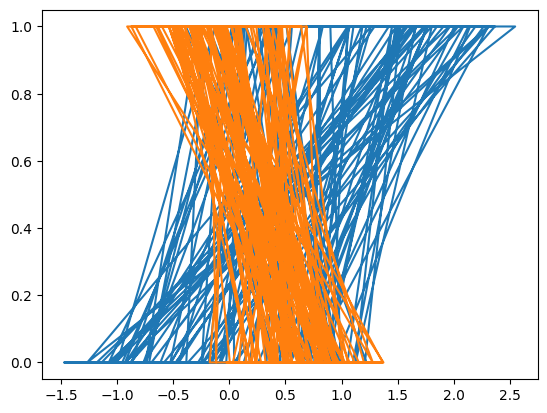

In [44]:
import matplotlib.pyplot as plt
plt.plot(X_train, y_train)

In [48]:
y_train.reshape(-1, 1)

tensor([[1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
      

In [49]:
NN = NeuralNetwork(input_size = X_train.shape[1], hidden_size1=8, hidden_size2=4, output_size=1, bias_value=-0.1)
NN.train(X_train,y_train.reshape(-1,1))

tensor([[-0.5469, -0.2185, -0.2817, -0.3597, -1.0559, -2.0843,  1.8202, -1.2477],
        [-0.0327, -1.7009,  0.5871, -1.7534,  1.6806,  0.1093,  0.7862,  1.3410]])
Loss: 1.198582410812378, accuracy: 0.3541666567325592
tensor([[-0.5477, -0.2194, -0.2825, -0.3589, -1.0550, -2.0835,  1.8193, -1.2485],
        [-0.0318, -1.7001,  0.5879, -1.7543,  1.6797,  0.1085,  0.7870,  1.3418]])
Loss: 1.1946406364440918, accuracy: 0.3583333194255829
tensor([[-0.5487, -0.2203, -0.2835, -0.3580, -1.0541, -2.0825,  1.8184, -1.2494],
        [-0.0309, -1.6992,  0.5888, -1.7552,  1.6788,  0.1076,  0.7879,  1.3427]])
Loss: 1.1900948286056519, accuracy: 0.3583333194255829
tensor([[-0.5496, -0.2212, -0.2844, -0.3570, -1.0532, -2.0816,  1.8175, -1.2504],
        [-0.0300, -1.6982,  0.5898, -1.7561,  1.6779,  0.1066,  0.7889,  1.3437]])
Loss: 1.1852772235870361, accuracy: 0.3583333194255829
tensor([[-0.5506, -0.2222, -0.2854, -0.3561, -1.0522, -2.0807,  1.8165, -1.2513],
        [-0.0290, -1.6973,  0.5907, -1.

[tensor(1.1986),
 tensor(1.1946),
 tensor(1.1901),
 tensor(1.1853),
 tensor(1.1803),
 tensor(1.1752),
 tensor(1.1701),
 tensor(1.1650),
 tensor(1.1598),
 tensor(1.1546)]